# Real-time Object Detection

In this project, we implemented a real-time object detection system using OpenCV and a pre-trained MobileNet Single Shot Detector (SSD) model. The system can detect and label multiple classes of everyday objects in static images, live webcam feeds, and video streams. The goal was to create a lightweight, real-time application capable of running efficiently on standard hardware.

MobileNet SSD was chosen for its excellent trade-off between accuracy and speed, which is essential for real-time applications. The object detection is based on deep learning and uses the Caffe deep learning framework to load the trained model. The project supports visualization of detection results along with FPS (Frames Per Second) information to evaluate the system's performance.

# Requirements

In [16]:
# import the necessary packages
from matplotlib import pyplot as plt
import numpy as np
import os
import cv2
import time

# Loading Model

Here, we defined the model architecture file (.prototxt) and weights file (.caffemodel). Set a confidence threshold of 20%, below which predictions are discarded.
Also, we listed the 21 object categories the model can detect (e.g., person, car, dog). Generated random RGB colors to uniquely color-code each class label.

In [17]:
PROTOTXT_ADDRESS = os.path.join("model", "deploy.prototxt")
MODEL_ADDRESS = os.path.join("model", "mobilenet_iter_73000.caffemodel")
CONFIDENCE = 0.2

# initialize the list of class labels MobileNet SSD was trained to
# detect, then generate a set of bounding box colors for each class
CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor",
]

COLORS = np.random.uniform(0, 255, size=(len(CLASSES), 3))

# load our serialized model from disk
net = cv2.dnn.readNetFromCaffe(PROTOTXT_ADDRESS, MODEL_ADDRESS)

# Object Detection Function

This function, ```detect_object()```, encapsulates the main detection logic. It takes an input image (frame) and a loaded network (network), converts the image into a standardized blob format required by the model, and feeds it through the network to obtain predictions. For each detected object, the function checks if the confidence score exceeds the predefined threshold. If it does, the function extracts the class index, computes bounding box coordinates, and draws a rectangle with a label on the image using OpenCV drawing functions. The modified image is returned with all detected objects highlighted.

In [18]:
def detect_object(frame, network):
    # grab the frame dimensions and convert it to a blob
    (h, w) = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 0.007843, (300, 300), 127.5)

    # pass the blob through the network and obtain the detections and predictions
    network.setInput(blob)
    detections = network.forward() 

    # loop over the detections
    for i in np.arange(0, detections.shape[2]):
        # extract the confidence (i.e., probability) associated with
		# the prediction
        confidence = detections[0, 0, i, 2]

        # filter out weak detections by ensuring the `confidence` is
		# greater than the minimum confidence
        if confidence > CONFIDENCE:
            # extract the index of the class label from the
			# `detections`, then compute the (x, y)-coordinates of
			# the bounding box for the object
            idx = int(detections[0, 0, i, 1])
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype('int')

            # draw the prediction on the frame
            label = "{}: {:.2f}%".format(CLASSES[idx], confidence * 100)
            cv2.rectangle(frame, (startX, startY), (endX, endY), COLORS[idx], 2)
            y = startY - 15 if startY - 15 > 15 else startY + 15
            cv2.putText(frame, label, (startX, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORS[idx], 2)
    return frame

# Testing Object Detection Function

In this section, the object detection functionality is tested on a static image named ```kid1.jpg```. The image is read using OpenCV and converted from RGB to BGR to align with OpenCV's default color format. The detection function is then applied, and the result is saved and visualized using ```matplotlib```. Two plots are displayed: one showing the original image and the other showing the image with detected objects. This test demonstrates that the object detection pipeline works correctly for still images before moving on to video streams.

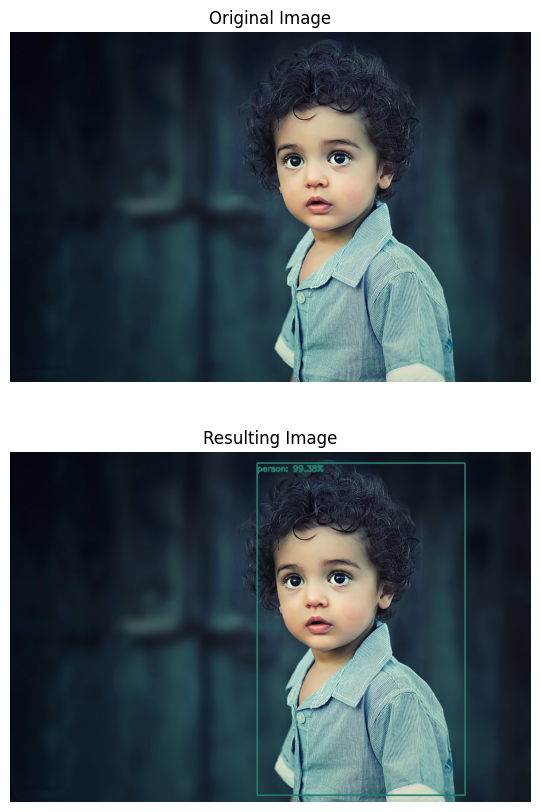

In [19]:
# Read the input image from the specified file path
image = cv2.imread("images/kid1.jpg")

# Convert the image from RGB to BGR color space (OpenCV uses BGR by default)
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

# Create a figure for displaying images with a specified size of 10x10 inches
resulting_image = detect_object(image.copy(), net)
cv2.imwrite("output/kid1_object_detected.jpg", cv2.cvtColor(resulting_image, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(resulting_image)
plt.title("Resulting Image")
plt.axis("off")

plt.show()

# Real-time Object Detection Using WebCam

To evaluate the efficiency of the system in real-time settings, an auxiliary function ```visualize_fps()``` is created. This function overlays the current FPS value on top of the video frame using OpenCV’s putText() function. The FPS value is calculated in other parts of the code and passed to this function. It smartly chooses white or green text depending on whether the image is grayscale or colored. This overlay helps in monitoring the system’s real-time performance.

In [20]:
def visualize_fps(image, fps: int):
    # Check if the image is grayscale or colored.
    # If it's grayscale, set text color to white; if colored, set text color to green.
    if len(np.shape(image)) < 3:
        text_color = (255, 255, 255)  # White color for grayscale images.
    else:
        text_color = (0, 255, 0)  # Green color for colored images.

    # Define the row size for the text placement.
    row_size = 20 
    # Define the left margin for the text placement.
    left_margin = 24 

    # Set the font size and thickness for the text.
    font_size = 1
    font_thickness = 2

    # Format the FPS value into a string for displaying.
    fps_text = "FPS = {:.1f}".format(fps)
    # Set the text location on the image.
    text_location = (left_margin, row_size)
    
    # Place the FPS text on the image.
    cv2.putText(
        image,
        fps_text,
        text_location,
        cv2.FONT_HERSHEY_PLAIN,
        font_size,
        text_color,
        font_thickness,
    )

    # Return the modified image with the FPS text.
    return image

This block handles real-time detection from a webcam feed. The script captures video using OpenCV's ```VideoCapture``` from device ID 0 (default webcam), processes each frame through the ```detect_object()``` function, overlays FPS using ```visualize_fps()```, and displays the results in a live OpenCV window. The processed video is also written to disk as an output ```.avi``` file using ```VideoWriter```. The loop continues until the user presses the Esc key, ensuring an interactive experience. FPS is calculated per frame, giving real-time performance feedback.

In [23]:
# Constants for camera settings
CAMERA_DEVICE_ID = 0  # ID for the camera device
IMAGE_WIDTH = 800  # Width of the captured image
IMAGE_HEIGHT = 600  # Height of the captured image
fps = 0  # Initial Frames Per Second (FPS) value

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID) # Initialize video capture with the specified camera device ID
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter("output/webcam_object_detected.avi", fourcc, 10, (IMAGE_WIDTH, IMAGE_HEIGHT))
        while True:  # Infinite loop to continuously capture frames

            start_time =  time.time()  # Record the start time to calculate FPS

            _, frame =  cap.read()  # Capture a single frame from the camera

            frame =  cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Resize the frame to the specified dimensions

            frame =  detect_object(frame, net)

            out.write(frame)  # Write the processed frame to the output video file
            cv2.imshow("frame", visualize_fps(frame, fps))

            end_time =  time.time()  # Record the end time to calculate FPS

            # Calculate the time taken to process the frameame with FPS overlay
            cv2.imshow("frame", visualize_fps(frame, fps)) 

            end_time =  time.time()  # Record the end time to calculate FPS

            # Calculate the time taken to process the frame
            seconds =  end_time - start_time
            # Calculate FPS based on the time taken to process the frame
            fps =  1.0 / seconds

            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(33) == 27:  
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the camera resource
        out.release()


# Real-time Object Detection Using Video Stream

The final cell replicates the webcam logic but uses a pre-recorded video file (```Jobs_1.mp4```) instead of a live stream. Each frame from the video is resized, processed by the detection function, and annotated with FPS information. An additional control mechanism ensures that each frame adheres to a target frame rate (30 FPS) by calculating processing time and sleeping for the remainder of the frame duration if necessary. This keeps playback smooth and consistent. The result is also saved to an output file and shown live in a window, providing a complete end-to-end demonstration of object detection on video data.

In [22]:
# Constants for video settings
# Define the path to the video file using os.path.join
CAMERA_DEVICE_ID = os.path.join("videos", "Jobs_1.mp4")  # Path to the video file
IMAGE_WIDTH = 1000  # Width of the displayed image
IMAGE_HEIGHT = 600  # Height of the displayed image
fps = 0  # Initial Frames Per Second (FPS) value
FRAME_RATE = 30  # Desired frame rate
DURATION = 1 / FRAME_RATE  # Duration of each frame

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap =  cv2.VideoCapture(CAMERA_DEVICE_ID) # Initialize video capture with the specified video file path
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter("output/video_object_detected.avi", fourcc, 10, (IMAGE_WIDTH, IMAGE_HEIGHT))
        while True:  # Infinite loop to continuously capture frames
            start_time =  time.time() # Record the start time to calculate FPS

            _, frame =  cap.read()  # Capture a single frame from the video
            frame =  cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Resize the frame to the specified dimensions
            frame = detect_object(frame, net) # Detect objects using detect_object()
            end_time = time.time()  # Record the end time to calculate FPS

            # Calculate the time taken to process the frame
            seconds = end_time - start_time

            # If the processing time is less than the desired frame duration, wait for the remaining time
            if seconds < DURATION:
                time.sleep(DURATION - seconds)

            # Recalculate the time taken to process the frame including sleep time
            seconds = end_time - start_time
            # Calculate FPS based on the time taken to process the frame
            fps = 1.0 / seconds

            # Display the frame with FPS overlay
            cv2.imshow("frame", visualize_fps(frame, fps))

            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(33) == 27:  
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the video capture resource
        out.release()

OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

